In [1]:
# Multi Layer Perceptron으로 손글씨 분류

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
digits = load_digits()
# digits는 0~9까지 숫자를 손으로 쓴 이미지 데이터임
# 이미지는 0~15 명암 가지는 8x8 픽셀 흑백 이미지
# 이미지 1797개

In [8]:
print(digits.images[0]) # 0번의 이미지 출력

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [9]:
print(digits.target[0]) # 0번의 이미지가 무엇인지 label 확인

0


In [10]:
print('전체 샘플 수 : {}'.format(len(digits.images)))

전체 샘플 수 : 1797


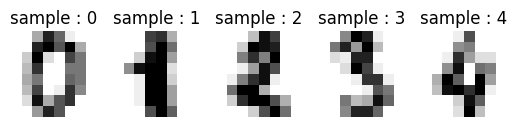

In [11]:
# 상위 5개 샘플만 시각화 함
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:5]):
    plt.subplot(2,5,index + 1)
    plt.axis('off')
    plt.imshow(image, cmap = plt.cm.gray_r, interpolation = 'nearest')
    plt.title('sample : %i' % label)

In [12]:
for i in range(5):
    print(i, '번 인덱스 샘플의 레이블', digits.target[i])

0 번 인덱스 샘플의 레이블 0
1 번 인덱스 샘플의 레이블 1
2 번 인덱스 샘플의 레이블 2
3 번 인덱스 샘플의 레이블 3
4 번 인덱스 샘플의 레이블 4


In [13]:
print(digits.data[0]) # 8x8 matrix가 아니라 64차원 vector으로 출력

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [14]:
X = digits.data # 이미지
Y = digits.target # 레이블

In [15]:
import torch
import torch.nn as nn
from torch import optim

In [32]:
# 정리
# input data는 64차원의 vector임
# output형태는 10개가 나와야함. 0~9 의 숫자를 분류해야하기 때문

In [16]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16, 10),
)

In [18]:
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.int64)

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_15644\2830600874.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype = torch.float32)
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_15644\2830600874.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y, dtype = torch.int64)


In [19]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
losses = []

In [24]:
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print('Epoch {:4d}/{} cost : {:.6f}'.format(
            epoch, 100, loss.item()
        ))

    losses.append(loss.item())

Epoch    0/100 cost : 0.393942
Epoch   10/100 cost : 0.301615
Epoch   20/100 cost : 0.237929
Epoch   30/100 cost : 0.193690
Epoch   40/100 cost : 0.161940
Epoch   50/100 cost : 0.138649
Epoch   60/100 cost : 0.120563
Epoch   70/100 cost : 0.106088
Epoch   80/100 cost : 0.094255
Epoch   90/100 cost : 0.084365


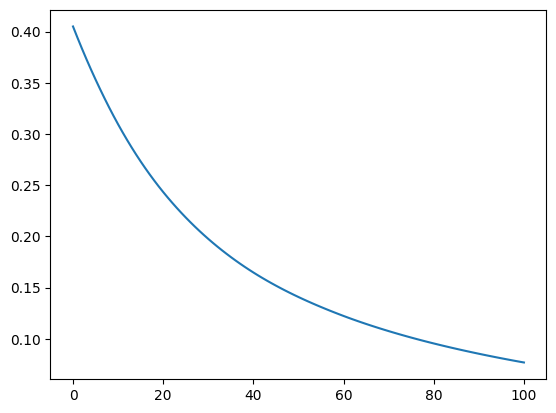

In [25]:
plt.plot(losses)